## Ejercicio 7

Utilizando la colección de prueba Vaswani y pyTerrier se debe realizar la evaluación del sistema. Para ello, es necesario construir un índice con los documentos de la colección y luego ejecutar las consultas (modelo vectorial con TF/IDF), las cuales deben armar a partir de los términos que considere de las necesidades de información (puede eliminar las palabras vacías). Los resultados deben ser comparados contra los juicios de relevancia de la colección. Realizar el análisis en dos ámbitos:

a)	Global (promedio de todas la consultas), para las siguientes métricas: P@10, AP, NDCG@10 e incluya la gráfica de R–P en los 11 puntos estándar. 

b)	Individual (por query), para las mismas métricas, calculando la distribución de los valores en cada caso.

## 1. Inicializacion PyTerrier

In [16]:
import pandas as pd
import pyterrier as pt
import os
if not pt.java.started():
  pt.java.init()

## 2. Indexacion

In [17]:
files = pt.io.find_files("../Colecciones/vaswani/")

#Crear el indexador - Ruta absoluta
index_path = os.path.abspath("index_vaswani")

# Crear carpeta si no existe
os.makedirs(index_path, exist_ok=True)

print("Index path:", index_path)

indexer = pt.TRECCollectionIndexer(index_path, overwrite=True, verbose=True)

indexref = indexer.index(files) 

Index path: c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP2\EJ7\index_vaswani


  0%|          | 0/16 [00:00<?, ?files/s]

02:57:08.192 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/corpus\.complete. Perhaps trec.collection.class is wrongly set, TrecDocTags are incorrect, or decompression failed
02:57:10.774 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/index\terrier_stemmed\.complete. Perhaps trec.collection.class is wrongly set, TrecDocTags are incorrect, or decompression failed
02:57:10.781 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/index\terrier_stemmed\data.direct.bf. Perhaps trec.collection.class is wrongly set, TrecDocTags are incorrect, or decompression failed
02:57:10.786 [main] WARN org.terrier.indexing.MultiDocumentFileCollection -- TRECCollection found no documents in ../Colecciones/vaswani/index\terrier_stemmed\data.document.fsarrayfile. Perhaps trec.collection

17files [00:02,  6.25files/s]            

02:57:11.048 [main] ERROR org.terrier.structures.indexing.Indexer -- Could not rename index
java.io.IOException: Rename of index structure file 'c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP2\EJ7\index_vaswani/data_1.direct.bf' (exists) to 'c:\Universidad\2026\Recuperacion de la Informacion\RI-JosueGaticaOdato\TP2\EJ7\index_vaswani/data.direct.bf' (exists) failed - likely that source file is still open. Possible indexing bug?
	at org.terrier.structures.IndexUtil.renameIndex(IndexUtil.java:379)
	at org.terrier.structures.indexing.Indexer.index(Indexer.java:388)


17files [00:02,  5.79files/s]


### 2.1 Indice

In [18]:
index = pt.IndexFactory.of(indexref)

print("------ MI INDICE ------")
print(index.collectionStatistics)

------ MI INDICE ------
Number of documents: 11429
Number of terms: 7756
Number of postings: 224573
Number of fields: 0
Number of tokens: 271581
Field names: []
Positions:   false



### 2.2 Comparacion con la coleccion original indexada

In [19]:
vaswani_index = pt.IndexFactory.of("../Colecciones/vaswani/index/terrier_stemmed/data.properties")

print("------ INDICE ORIGINAL ------")
print(vaswani_index.collectionStatistics)

------ INDICE ORIGINAL ------
Number of documents: 11429
Number of terms: 7756
Number of postings: 224573
Number of fields: 1
Number of tokens: 271581
Field names: [text]
Positions:   false



In [20]:
# termino: 
# term5: Es el ID interno del término. Terrier asigna un número único 
# Nt=2: (Document Frequency) 
# TF=2: (Total Term Frequency) cf
# maxTF=1: Es la frecuencia máxima que alcanzó el termino un solo documento
# @{0 0 6} ID del archivo  (si el índice está dividido), desplazamiento (offset) en bytes
# bit exacto.


for kv in index.getLexicon():
  print(f"{kv.getKey()}: {kv.getValue().toString()}")

aa: term318 Nt=5 TF=5 maxTF=1 @{0 0 0}
aachen: term3072 Nt=1 TF=1 maxTF=1 @{0 10 0}
aad: term1784 Nt=2 TF=2 maxTF=1 @{0 12 6}
aan: term3885 Nt=2 TF=2 maxTF=1 @{0 17 6}
ab: term2352 Nt=6 TF=6 maxTF=1 @{0 21 4}
abac: term3257 Nt=3 TF=5 maxTF=3 @{0 37 4}
abandon: term6096 Nt=1 TF=1 maxTF=1 @{0 46 4}
abbrevi: term6509 Nt=3 TF=3 maxTF=1 @{0 49 6}
abd: term5292 Nt=1 TF=1 maxTF=1 @{0 55 4}
abel: term5204 Nt=2 TF=2 maxTF=1 @{0 58 6}
aber: term4071 Nt=1 TF=1 maxTF=1 @{0 65 0}
aberr: term2390 Nt=7 TF=10 maxTF=4 @{0 68 0}
abil: term2775 Nt=7 TF=7 maxTF=1 @{0 84 7}
abing: term5822 Nt=3 TF=3 maxTF=1 @{0 103 5}
abl: term4369 Nt=6 TF=6 maxTF=1 @{0 111 7}
ablat: term7513 Nt=1 TF=2 maxTF=2 @{0 126 5}
abnorm: term1881 Nt=35 TF=42 maxTF=2 @{0 130 2}
aboard: term7094 Nt=2 TF=2 maxTF=1 @{0 200 1}
abomb: term944 Nt=1 TF=1 maxTF=1 @{0 206 3}
abrad: term4946 Nt=3 TF=4 maxTF=2 @{0 208 1}
abraham: term4554 Nt=1 TF=1 maxTF=1 @{0 214 6}
abridg: term3075 Nt=1 TF=1 maxTF=1 @{0 217 6}
abrupt: term2098 Nt=5 TF=6 maxT

## 3. Modelo de Recuperacion

In [21]:
tfidf = pt.terrier.Retriever(index, wmodel="TF_IDF")

## 4. Necesidad de Informacion

In [29]:
import pandas as pd
import re

# Parseo de la query de la coleccion
def parse_queries(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    queries = []

    tops = content.split("<top>")

    for top in tops:
        if "<num>" in top:
            # Obtener qid
            qid = re.search(r"<num>(\d+)</num>", top)
            qid = qid.group(1) if qid else None

            # Obtener query
            title = re.search(r"<title>(.*?)</title>", top, re.DOTALL)
            query = title.group(1).strip() if title else ""

            queries.append([qid, query])

    return pd.DataFrame(queries, columns=["qid", "query"])


topics = parse_queries("../Colecciones/vaswani/query-text.trec")
topics["qid"] = topics["qid"].astype(str)

topics

,qid,query
0,1,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
1,2,MATHEMATICAL ANALYSIS AND DESIGN DETAILS OF WA...
2,3,USE OF DIGITAL COMPUTERS IN THE DESIGN OF BAND...
3,4,SYSTEMS OF DATA CODING FOR INFORMATION TRANSFER
4,5,USE OF PROGRAMS IN ENGINEERING TESTING OF COMP...
...,...,...
88,89,TUNNEL DIODE CONSTRUCTION AND ITS ELECTRICAL C...
89,90,ELECTRONIC DENSITY OF STATES AT THE SURFACE OF...
90,91,RESISTIVITY OF METALLIC THIN FILMS RELATED TO ...
91,92,THE PHENOMENON OF RADIATION CAUSED BY CHARGED ...


## 5. Juicios de Relevancia

In [42]:
qrels = pd.read_csv(
    "../Colecciones/vaswani/qrels",
    delim_whitespace=True,
    names=["qid", "unused", "docno", "label"]
)

qrels = qrels[["qid", "docno", "label"]]
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)

qrels

C:\Users\Leone\AppData\Local\Temp\ipykernel_19676\3360858100.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  qrels = pd.read_csv(


,qid,docno,label
0,1,1239,1
1,1,1502,1
2,1,4462,1
3,1,4569,1
4,1,5472,1
...,...,...,...
2078,93,9875,1
2079,93,9956,1
2080,93,10497,1
2081,93,11191,1


## 6. Resultados

In [43]:
results = tfidf.transform(topics)
results["qid"] = results["qid"].astype(str)
results

,qid,docid,docno,rank,score,query
0,1,8171,8172,0,13.746087,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
1,1,9880,9881,1,12.352666,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
2,1,5501,5502,2,12.178153,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
3,1,1501,1502,3,10.993585,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
4,1,9858,9859,4,10.271452,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...
...,...,...,...,...,...,...
91925,93,2226,2227,995,4.904950,HIGH FREQUENCY OSCILLATORS USING TRANSISTORS T...
91926,93,6898,6899,996,4.899385,HIGH FREQUENCY OSCILLATORS USING TRANSISTORS T...
91927,93,3473,3474,997,4.898796,HIGH FREQUENCY OSCILLATORS USING TRANSISTORS T...
91928,93,3187,3188,998,4.893073,HIGH FREQUENCY OSCILLATORS USING TRANSISTORS T...


## 7. Experimento

### 7.1 Evaluacion Global

In [45]:
pt.Experiment(
    [tfidf],
    topics,
    qrels,
    eval_metrics=["P_10", "map", "ndcg_cut_10"],
    names=["TF-IDF"]
)

,name,map,P_10,ndcg_cut_10
0,TF-IDF,0.290905,0.35914,0.444411


### 7.2 Curva R-P

Recall: 0.0, Precision: 0.7254
Recall: 0.1, Precision: 0.6405
Recall: 0.2, Precision: 0.5208
Recall: 0.3, Precision: 0.4064
Recall: 0.4, Precision: 0.3362
Recall: 0.5, Precision: 0.2679
Recall: 0.6, Precision: 0.1978
Recall: 0.7, Precision: 0.1512
Recall: 0.8, Precision: 0.1042
Recall: 0.9, Precision: 0.0575
Recall: 1.0, Precision: 0.0240


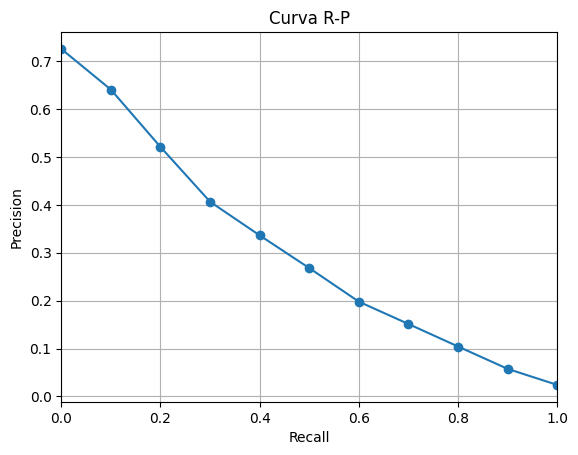

In [68]:
res = pt.Experiment(
    [tfidf],
    topics,
    qrels,
    eval_metrics=["iprec_at_recall"],
    names=["TF-IDF"]
)

#print(res)

import matplotlib.pyplot as plt

recall = [i/10 for i in range(11)]
precision = [res.iloc[0][f"IPrec@{i/10:.1f}"] for i in range(11)]
#precision

# Imprimir los resultados interpolados
for r, p in zip(recall, precision):
    print(f"Recall: {r:.1f}, Precision: {p:.4f}")

plt.plot(recall, precision, marker='o', label='Precision interpolada')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva R-P")
plt.grid(True)
plt.xlim(0, 1)
plt.show()

### 7.3 Evaluacion Individual

In [62]:
por_query = pt.Experiment(
    [tfidf],
    topics,
    qrels,
    eval_metrics=["P_10", "map", "ndcg_cut_10"],
    perquery=True,
    names=["TF-IDF"]
)

por_query

,name,qid,measure,value
0,TF-IDF,1,map,0.268860
1,TF-IDF,1,P_10,0.500000
2,TF-IDF,1,ndcg_cut_10,0.573690
27,TF-IDF,10,map,0.121486
28,TF-IDF,10,P_10,0.200000
...,...,...,...,...
274,TF-IDF,92,P_10,0.200000
275,TF-IDF,92,ndcg_cut_10,0.179931
276,TF-IDF,93,map,0.230467
277,TF-IDF,93,P_10,0.300000


In [64]:
por_query_wide = por_query.pivot(
    index="qid",
    columns="measure",
    values="value"
)

print(por_query_wide.head())

measure  P_10       map  ndcg_cut_10
qid                                 
1         0.5  0.268860     0.573690
10        0.2  0.121486     0.224006
11        0.0  0.067998     0.000000
12        0.4  0.209372     0.328062
13        0.4  0.269452     0.407415


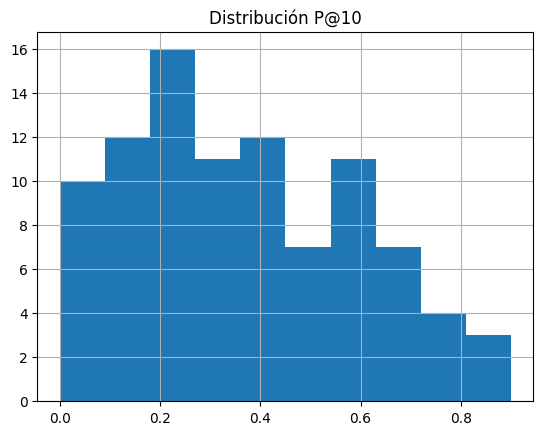

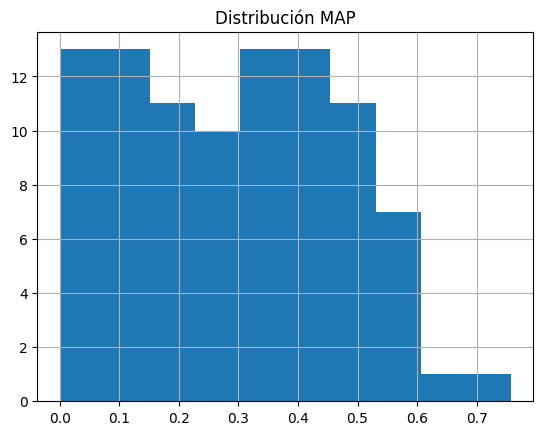

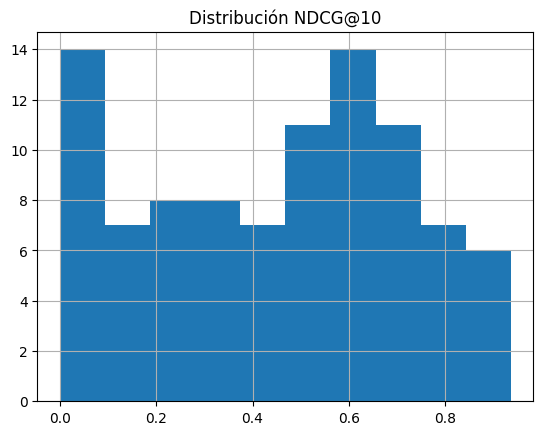

In [66]:
por_query_wide["P_10"].hist()
plt.title("Distribución P@10")
plt.show()

por_query_wide["map"].hist()
plt.title("Distribución MAP")
plt.show()

por_query_wide["ndcg_cut_10"].hist()
plt.title("Distribución NDCG@10")
plt.show()